# PSR J0537-6910 — Modelo vs Datos Observacionales

Este notebook compara el modelo de rotación del púlsar (obtenido del archivo `.par`) con datos observacionales independientes (archivo `.dat`).

## Modelo teórico

La frecuencia de rotación se describe como expansión de Taylor:

$$F_0(t) = F_0 + F_1 t' + \frac{1}{2}F_2 t'^2 + \frac{1}{6}F_3 t'^3 + \sum_i \Delta F_{0,i}(t)$$

$$F_1(t) = F_1 + F_2 t' + \frac{1}{2}F_3 t'^2 + \sum_i \Delta F_{1,i}(t)$$

donde $t' = (t - \text{PEPOCH})$ en segundos y los términos $\Delta F_{0,i}$, $\Delta F_{1,i}$ son las contribuciones de cada glitch.

## Modelo de glitches

Cada glitch $i$ ocurre en la época $t_{g,i}$ (GLEP) y produce saltos permanentes en $F_0$ y $F_1$. Para $t > t_{g,i}$, su contribución es:

$$\Delta F_{0,i}(t) = \text{GLF0}_i + \text{GLF1}_i \cdot (t - t_{g,i}) + \frac{1}{2}\text{GLF2}_i \cdot (t - t_{g,i})^2$$

$$\Delta F_{1,i}(t) = \text{GLF1}_i + \text{GLF2}_i \cdot (t - t_{g,i})$$

Físicamente: un glitch es un aumento abrupto en $F_0$ (el púlsar gira de repente más rápido), seguido de una relajación gradual mediada por $\text{GLF1}_i < 0$ (frenado post-glitch más intenso).

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import re

# ── Configuración central del notebook ─────────────────────────────────────
CONFIG = {
    'PAR_FILE': 'par_files/nicer-paper.par',
    'DAT_FILE': 'dat_files/nicervf_sm5-20.dat',
    'USAR_GLITCHES': True,
    'GLITCHES_IGNORAR': [],
}

---
## 1. Lectura del archivo `.par`

Se extraen los parámetros de rotación base ($F_0, F_1, F_2, F_3$, PEPOCH) y los parámetros de cada glitch (GLEP, GLF0, GLF1, GLF2).

Se muestra además un resumen de parámetros y glitches detectados, con validación básica de campos faltantes.

In [69]:
def leer_par(filename):
    params = {}
    glitches_raw = {}
    reporte = {
        'lineas_leidas': 0,
        'lineas_validas': 0,
        'parametros_invalidos': 0,
        'glitches_incompletos': 0,
    }

    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            reporte['lineas_leidas'] += 1
            line = re.sub(r'\\', '', line).strip()
            if not line or line.startswith('#'):
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            reporte['lineas_validas'] += 1
            key, val_str = parts[0], parts[1]

            m = re.match(r'(GLEP|GLF0|GLF1|GLF2)_(\d+)', key)
            if m:
                gl_param = m.group(1)
                gl_idx = int(m.group(2))
                glitches_raw.setdefault(gl_idx, {})
                try:
                    glitches_raw[gl_idx][gl_param] = float(val_str)
                except ValueError:
                    reporte['parametros_invalidos'] += 1
                continue

            try:
                if ':' not in val_str:
                    params[key] = float(val_str)
            except ValueError:
                reporte['parametros_invalidos'] += 1

    glitches = [glitches_raw[i] for i in sorted(glitches_raw)]

    for g in glitches:
        if 'GLEP' not in g:
            reporte['glitches_incompletos'] += 1

    params['glitches'] = glitches
    return params, reporte


---
## 2. Lectura del archivo `.dat`

El archivo `.dat` contiene mediciones observacionales con las columnas:

| Col | Descripción | Unidades originales | Factor de escala |
|-----|-------------|---------------------|------------------|
| 0   | MJD         | días                | —                |
| 1   | F0          | Hz                  | ×1               |
| 2   | err_F0      | Hz                  | ×1               |
| 3   | F1          | 1×10⁻¹⁵ Hz/s        | ×1×10⁻¹⁵         |
| 4   | err_F1      | 1×10⁻¹⁵ Hz/s        | ×1×10⁻¹⁵         |
| 5   | F2          | 1×10⁻²⁴ Hz/s²       | ×1×10⁻²⁴         |
| 6   | err_F2      | 1×10⁻²⁴ Hz/s²       | ×1×10⁻²⁴         |

In [70]:
def leer_dat(filename):
    mjd, f0, err_f0, f1, err_f1 = [], [], [], [], []
    reporte = {'lineas_leidas': 0, 'lineas_usadas': 0, 'lineas_descartadas': 0}

    with open(filename, 'r', encoding='utf-8') as fh:
        for line in fh:
            reporte['lineas_leidas'] += 1
            line = line.strip()
            if not line or line.startswith('#'):
                continue

            cols = line.split()
            if len(cols) < 5:
                reporte['lineas_descartadas'] += 1
                continue

            try:
                mjd.append(float(cols[0]))
                f0.append(float(cols[1]))
                err_f0.append(float(cols[2]))
                f1.append(float(cols[3]) * 1e-15)
                err_f1.append(float(cols[4]) * 1e-15)
                reporte['lineas_usadas'] += 1
            except ValueError:
                reporte['lineas_descartadas'] += 1

    datos = {
        'mjd': np.array(mjd),
        'f0': np.array(f0),
        'err_f0': np.array(err_f0),
        'f1': np.array(f1),
        'err_f1': np.array(err_f1),
    }

    order = np.argsort(datos['mjd'])
    for k in datos:
        datos[k] = datos[k][order]

    return datos, reporte

In [76]:
# -----------------------------------------------------------------
# MODELO
# -----------------------------------------------------------------

def calcular_modelo(params, t_mjd_array, usar_glitches=True, glitches_ignorar=None):
    if glitches_ignorar is None:
        glitches_ignorar = []

    F0 = params.get('F0', 0.0)
    F1 = params.get('F1', 0.0)
    F2 = params.get('F2', 0.0)
    F3 = params.get('F3', 0.0)
    PEPOCH = params.get('PEPOCH', 0.0)

    t = (np.array(t_mjd_array) - PEPOCH) * 86400.0

    f0 = F0 + F1*t + 0.5*F2*t**2 + (1/6)*F3*t**3
    f1 = F1 + F2*t + 0.5*F3*t**2

    if usar_glitches:
        for idx, g in enumerate(params.get('glitches', []), start=1):
            if idx in glitches_ignorar:
                continue
            if 'GLEP' not in g:
                continue

            t_g = (g['GLEP'] - PEPOCH) * 86400.0
            mask = t > t_g
            dt = t[mask] - t_g

            f0[mask] += (
            g.get('GLF0', 0.0) +
            g.get('GLF1', 0.0)*dt +
            0.5*g.get('GLF2', 0.0)*dt**2
            )

            f1[mask] += (
            g.get('GLF1', 0.0) +
            g.get('GLF2', 0.0)*dt
            )

    return f0, f1

def calcular_fase(params, t_mjd, usar_glitches=True):
    F0, F1, F2, F3 = [params.get(k, 0.0) for k in ['F0','F1','F2','F3']]
    PEPOCH = params.get('PEPOCH', 0.0)

    t = (np.asarray(t_mjd) - PEPOCH) * 86400.0

    phi = (
        F0*t +
        0.5*F1*t**2 +
        (1/6)*F2*t**3 +
        (1/24)*F3*t**4
    )

    if usar_glitches:
        for g in params.get('glitches', []):
            if 'GLEP' not in g:
                continue

            t_g = (g['GLEP'] - PEPOCH) * 86400.0
            mask = t > t_g
            dt = t[mask] - t_g

            phi[mask] += (
                g.get('GLF0',0)*dt +
                0.5*g.get('GLF1',0)*dt**2 +
                (1/6)*g.get('GLF2',0)*dt**3
            )

    return phi


In [77]:
# -----------------------------------------------------------------
# Derivadas de la fase
# -----------------------------------------------------------------

params, _ = leer_par(CONFIG['PAR_FILE'])
datos, _ = leer_dat(CONFIG['DAT_FILE'])

f0_model, f1_model = calcular_modelo(params, datos['mjd'], CONFIG['USAR_GLITCHES'])
phi = calcular_fase(params, datos['mjd'], CONFIG['USAR_GLITCHES'])

# Tiempo relativo
t = (datos['mjd'] - params.get('PEPOCH', datos['mjd'][0])) * 86400.0

# φ̇ y φ̈ CONSISTENTES (derivadas numéricas)
phi_dot = np.gradient(phi, t)
phi_ddot = np.gradient(phi_dot, t)

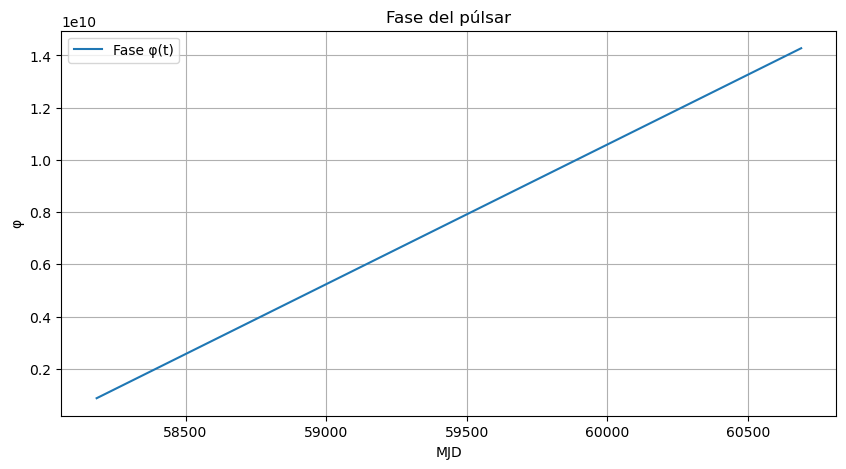

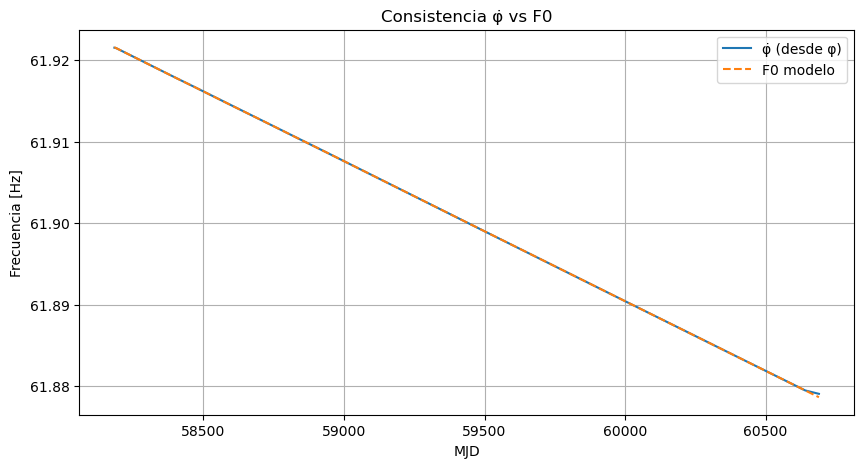

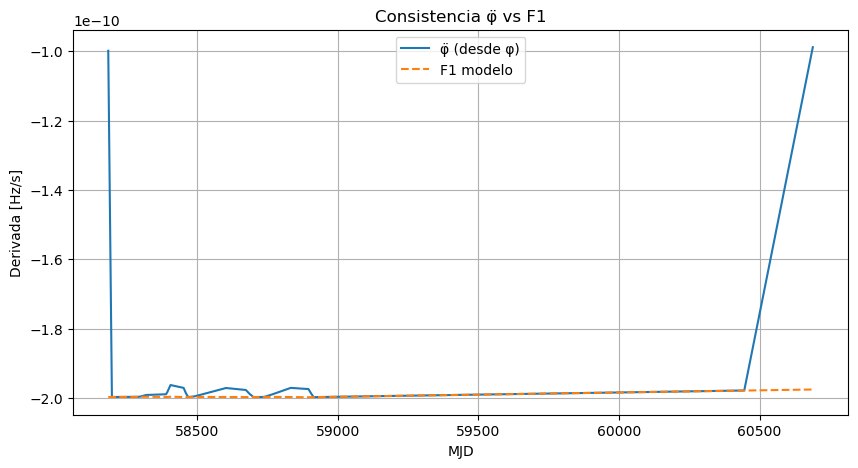

In [78]:
# -----------------------------------------------------------------
# GRAFICOS
# -----------------------------------------------------------------

# φ(t)
plt.figure(figsize=(10,5))
plt.plot(datos['mjd'], phi, label='Fase φ(t)')
plt.xlabel('MJD'); plt.ylabel('φ')
plt.title('Fase del púlsar')
plt.legend(); plt.grid(); plt.show()

# φ̇ vs F0
plt.figure(figsize=(10,5))
plt.plot(datos['mjd'], phi_dot, label='φ̇ (desde φ)')
plt.plot(datos['mjd'], f0_model, '--', label='F0 modelo')
plt.xlabel('MJD'); plt.ylabel('Frecuencia [Hz]')
plt.title('Consistencia φ̇ vs F0')
plt.legend(); plt.grid(); plt.show()

# φ̈ vs F1
plt.figure(figsize=(10,5))
plt.plot(datos['mjd'], phi_ddot, label='φ̈ (desde φ)')
plt.plot(datos['mjd'], f1_model, '--', label='F1 modelo')
plt.xlabel('MJD'); plt.ylabel('Derivada [Hz/s]')
plt.title('Consistencia φ̈ vs F1')
plt.legend(); plt.grid(); plt.show()


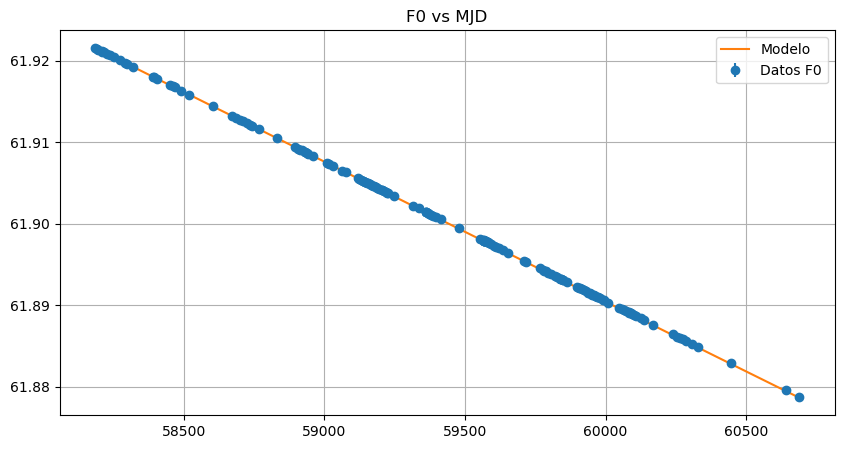

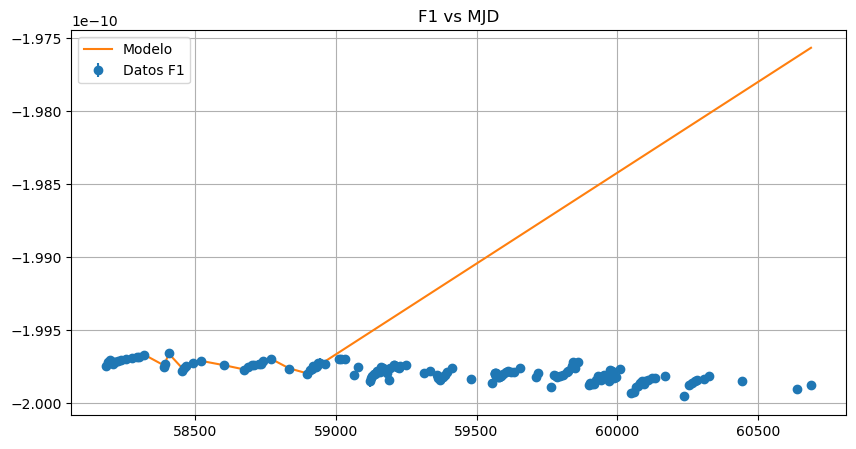

In [79]:
# Datos vs modelo
plt.figure(figsize=(10,5))
plt.errorbar(datos['mjd'], datos['f0'], yerr=datos['err_f0'], fmt='o', label='Datos F0')
plt.plot(datos['mjd'], f0_model, label='Modelo')
plt.legend(); plt.grid(); plt.title('F0 vs MJD')
plt.show()

plt.figure(figsize=(10,5))
plt.errorbar(datos['mjd'], datos['f1'], yerr=datos['err_f1'], fmt='o', label='Datos F1')
plt.plot(datos['mjd'], f1_model, label='Modelo')
plt.legend(); plt.grid(); plt.title('F1 vs MJD')
plt.show()